# D.R.O.N.A. — 01 · Data Cleaning & Preprocessing

Builds and audits every dataset the project trains on, then saves clean,
validated artifacts for the rest of the pipeline.

```
01 data cleaning  ->  02 EDA  ->  03 feature engineering  ->  04 model training  ->  05 evaluation
   & preprocessing                   (dual embeddings)          (Colab A100)          & comparison
```

**Runtime:** CPU is enough (~10 min incl. downloads). GPU is not used here.
**Inputs:** raw O*NET download (fetched below), `data/raw/curriculum/`, `data/manual_collection/`.
**Outputs:** `data/processed/*.{parquet,json}`, `data/finetune/sft_*.jsonl`,
`data/demonstrations/demonstrations.jsonl`, per-dataset data cards, `reports/cleaning_report.json`.

## Dataset selection — what we use and why

Each source was chosen as the highest-quality, openly licensed dataset available
for its role; provenance and licensing are documented per-dataset in
[`docs/data_ethics.md`](../../docs/data_ethics.md) and `docs/data_cards/`.

| # | Dataset | Version | License | Why this one | Role in D.R.O.N.A. |
|---|---------|---------|---------|--------------|--------------------|
| 1 | **O*NET** (US Dept. of Labor) | 30.3 | CC BY 4.0 | The most comprehensive, professionally curated occupational database available (~900 occupations with skills, education, and work context per SOC code); the de-facto standard knowledge base in career-guidance research | Parsed into 39 computing `CareerPathway`s → career retrieval collection + grounding for the SFT dataset |
| 2 | **ESCO** (European Commission) | v1.2.1 | CC BY 4.0 | The EU's multilingual occupation/skill taxonomy; its ICT skill taxonomy is finer-grained than O*NET's and maps cleanly into the JobBERT career-embedding space | Optional second international tier of career pathways (ISCO group 25 = ICT professionals) |
| 3 | **BLS OEWS** (US Bureau of Labor Statistics) | May 2025 | Public domain | Authoritative wage percentiles per SOC occupation — the reference source for US salary statistics | International salary bands attached to O*NET pathways; presented *against* Nepal-tier evidence (anti-anchoring, C2/C4) |
| 4 | **NLFS** (Nepal National Statistics Office) | 2017/18 | Open government data | The flagship official Nepal labour-market survey — the strongest Nepal-tier evidence that exists | Text evidence snippets with page provenance for Nepal-grounded citations (C4) |
| 5 | **Softwarica curriculum** | current | Institution-provided | Ground truth for what students actually study — no public substitute exists | Curriculum retrieval collection (C1). *Placeholder module docs ship with the repo; replace with real descriptors for a real model* |
| 6 | **MeroJob postings** (manual collection) | rolling | Manually collected, ToS-verified | True local demand signal; no clean public Nepali job dataset exists, so postings are collected manually with robots.txt/ToS checks | Nepal-tier career documents (C4). *Placeholder postings ship with the repo* |
| 7 | Synthetic advising Q&A | generated | — (labelled `SYNTHETIC`) | Grounded in the real pathways/modules above; bias-type balanced by construction | LoRA fine-tune (SFT) input for the advising LLM |
| 8 | Gesture demonstrations | generated | — | Keyframe + jitter demonstrations give dense, controlled training data without robot hardware | ACT / Diffusion / BC gesture-policy training |

> **Placeholder note:** datasets 5–6 ship as clearly marked placeholders so the
> whole pipeline runs end-to-end today. Swap in the real files
> (`data/raw/curriculum/`, `data/manual_collection/`) and re-run this notebook
> before training the final thesis models.

## 0 · Colab setup

In [7]:
import os, sys, subprocess, pathlib

gpu = ""
try:
    gpu = subprocess.run(["nvidia-smi", "-L"], capture_output=True, text=True, check=False).stdout.strip()
except FileNotFoundError:
    gpu = "No GPU detected - nvidia-smi command not found."
print(gpu or "No GPU detected - see the note at the top of this notebook.")

# EDIT this to your GitHub repo URL. Private repo? use a fine-grained read
# token: https://<TOKEN>@github.com/<user>/D.R.O.N.A.git
# Alternatively upload a zip of the project (Colab Files panel) or attach it
# as a Kaggle dataset named 'drona' - the search loop below finds it.
REPO_URL = "https://github.com/trishan9/D.R.O.N.A.git"   # <-- EDIT ME

def _is_repo(p):
    return pathlib.Path(p, "drona", "__init__.py").is_file()

search = [".", "..", "../..", "D.R.O.N.A", "/content/D.R.O.N.A",
          "/kaggle/working/D.R.O.N.A", "/kaggle/input/drona/D.R.O.N.A", "/kaggle/input/drona"]
repo = next((p for p in search if _is_repo(p)), None)
if repo is None:
    dest = "/content/D.R.O.N.A" if pathlib.Path("/content").is_dir() else "D.R.O.N.A"
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, dest], check=True)
    repo = dest
assert repo and _is_repo(repo), (
    "Repo not found. Set REPO_URL to your GitHub URL, OR upload/attach the "
    "project, then re-run. See docs/COLAB_TRAINING_GUIDE.md.")
os.chdir(repo)
print("repo:", os.getcwd())

subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-e", ".[eval]"], check=False)
print("setup complete - continue to the next cell")

No GPU detected - nvidia-smi command not found.
repo: /content/D.R.O.N.A
setup complete - continue to the next cell


In [8]:
# ── Load & VERIFY the real private data (curriculum) — RUN AFTER SETUP ────────
# The real curriculum ships separately in drona_private_data.zip (it is
# gitignored). This cell puts it into the repo and HARD-STOPS on placeholder
# data, so you never train on dummies. It uses a DIRECT in-notebook upload
# (no Google Drive needed): the file picker BLOCKS this cell until you choose the
# zip, so later cells cannot run without the data. Re-running is safe — once the
# data is present it does nothing.
import glob, os, pathlib, subprocess

REPO = next((p for p in (".", "/content/D.R.O.N.A", "D.R.O.N.A", "..")
             if pathlib.Path(p, "drona", "__init__.py").is_file()), ".")

def _real_curriculum_count():
    d = pathlib.Path(REPO, "data/raw/curriculum")
    files = list(d.glob("*.md")) if d.is_dir() else []
    return sum(1 for f in files
               if "DUMMY / PLACEHOLDER" not in f.read_text(encoding="utf-8", errors="ignore")[:200])

def _unzip(z):
    print("unzipping", z, "...")
    subprocess.run(["unzip", "-oq", z, "-d", REPO], check=True)

if _real_curriculum_count() >= 40:
    print(f"real curriculum already present ({_real_curriculum_count()} modules) - OK to proceed")
else:
    # Reuse a bundle already on disk (Files-panel upload, Drive, or a prior run).
    found = (glob.glob("drona_private_data.zip")
             + glob.glob("/content/drona_private_data.zip")
             + glob.glob(f"{REPO}/drona_private_data.zip")
             + glob.glob("../drona_private_data.zip")
             + glob.glob("/content/drive/MyDrive/**/drona_private_data.zip", recursive=True)
             + glob.glob("/kaggle/input/**/drona_private_data.zip", recursive=True))
    if found:
        _unzip(found[0])
    else:
        try:
            from google.colab import files
        except ImportError:
            files = None
        if files is not None:
            print("\n" + "=" * 64)
            print(">>> Upload drona_private_data.zip now — click 'Choose Files'. <<<")
            print("    It is in your project folder on your PC (~4 MB).")
            print("=" * 64 + "\n")
            uploaded = files.upload()          # BLOCKS until the upload finishes
            zname = next((n for n in uploaded if n.lower().endswith(".zip")), None)
            if zname:
                if not os.path.exists(zname):
                    pathlib.Path(zname).write_bytes(uploaded[zname])
                _unzip(zname)

    n = _real_curriculum_count()
    if n < 40:
        raise SystemExit(
            f"\n*** REAL CURRICULUM NOT LOADED (only {n} real module files) ***\n"
            "Re-run THIS cell and upload drona_private_data.zip when the picker appears.")
    print(f"real curriculum loaded: {n} module files across all programmes - OK to proceed")



>>> Upload drona_private_data.zip now — click 'Choose Files'. <<<
    It is in your project folder on your PC (~4 MB).



Saving drona_private_data.zip to drona_private_data.zip
unzipping drona_private_data.zip ...
real curriculum loaded: 87 module files across all programmes - OK to proceed


In [9]:
# --- Shared plotting style: colorblind-safe palette, publication defaults ----
import random, pathlib
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

SEED = 42
random.seed(SEED); np.random.seed(SEED)

# Categorical palette - CVD-validated ordering. Never reorder or cycle it;
# a 9th series folds into "other".
C = ["#2a78d6", "#1baf7a", "#eda100", "#008300",
     "#4a3aa7", "#e34948", "#e87ba4", "#eb6834"]
INK = {"primary": "#0b0b0b", "secondary": "#52514e", "muted": "#898781",
       "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb"}
SEQ = LinearSegmentedColormap.from_list("drona_seq",
    ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"])
DIV = LinearSegmentedColormap.from_list("drona_div",
    ["#104281", "#5598e7", "#f0efec", "#e88a89", "#a52827"])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "figure.facecolor": INK["surface"], "axes.facecolor": INK["surface"],
    "axes.edgecolor": INK["axis"], "axes.linewidth": 0.8,
    "axes.grid": True, "grid.color": INK["grid"], "grid.linewidth": 0.6,
    "axes.axisbelow": True, "axes.spines.top": False, "axes.spines.right": False,
    "axes.titlelocation": "left", "axes.titleweight": "bold", "axes.titlesize": 12,
    "axes.labelcolor": INK["secondary"], "axes.labelsize": 10,
    "xtick.color": INK["muted"], "ytick.color": INK["muted"],
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "text.color": INK["primary"], "font.family": "sans-serif",
    "legend.frameon": False, "legend.fontsize": 9,
    "axes.prop_cycle": mpl.cycler(color=C),
})

FIG_DIR = pathlib.Path("reports/figures/01_cleaning")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def finish(ax, title, subtitle=None, xlabel=None, ylabel=None, grid_axis="y"):
    """Standard title/label treatment. grid_axis: which axis keeps gridlines."""
    ax.set_title(title, pad=22 if subtitle else 8)
    if subtitle:
        ax.text(0, 1.03, subtitle, transform=ax.transAxes,
                fontsize=9, color=INK["secondary"])
    if xlabel: ax.set_xlabel(xlabel)
    if ylabel: ax.set_ylabel(ylabel)
    ax.grid(visible=False, axis="x" if grid_axis == "y" else "y")
    return ax

def save_fig(fig, name):
    p = FIG_DIR / f"{name}.png"
    fig.savefig(p)
    print(f"figure saved -> {p}")

print("plot style ready; figures ->", FIG_DIR)

plot style ready; figures -> reports/figures/01_cleaning


## 1 · O*NET 30.3 — download, parse, validate

`drona.data_pipeline.onet` downloads the official release, filters to computing
occupations, and parses each into a Pydantic `CareerPathway`. Validation is
schema-first: a record that violates the contract (wrong types, missing
required fields, unknown extra fields) is rejected at parse time, so everything
downstream can trust the shape of the data.

In [10]:
from pathlib import Path
from drona.data_pipeline import onet

PROC = Path("data/processed"); PROC.mkdir(parents=True, exist_ok=True)
parquet = PROC / "onet_career_pathways.parquet"

zip_path = onet.download_zip()                    # cached after the first run
pathways = onet.parse(zip_path)                   # -> list[CareerPathway], schema-validated
onet.save_parquet(pathways, parquet)
onet.build_data_card(zip_path, pathways, parquet) # provenance data card
print(f"{len(pathways)} computing pathways -> {parquet}")

2026-07-14 04:56:52.243 | INFO     | drona.data_pipeline.onet:download_zip:86 - Downloading O*NET 30.3 from https://www.onetcenter.org/dl_files/database/db_30_3_text.zip
2026-07-14 04:56:52.985 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   0.5% (65,536 / 13,222,549 bytes)
2026-07-14 04:56:53.151 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   1.0% (131,072 / 13,222,549 bytes)
2026-07-14 04:56:53.206 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   1.5% (196,608 / 13,222,549 bytes)
2026-07-14 04:56:53.316 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   2.0% (262,144 / 13,222,549 bytes)
2026-07-14 04:56:53.372 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   2.5% (327,680 / 13,222,549 bytes)
2026-07-14 04:56:53.482 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   3.0% (393,216 / 13,222,549 bytes)
2026-07-14 04:56:53.537 | DEBUG    | drona.data_pipeline.onet:download_zip:97 -   3.5% (458,752 / 13,222,549 bytes)
2026-07-14 04:56:53

39 computing pathways -> data/processed/onet_career_pathways.parquet


In [11]:
import pandas as pd

pw = pd.DataFrame([p.model_dump() for p in pathways])
pw.head(3)

,pathway_id,title,tier,onet_soc_code,esco_code,description,typical_skills,typical_education,local_salary_range_npr,international_salary_range_usd,related_softwarica_modules,sample_employers_nepal
0,onet_11_3021_00,Computer and Information Systems Managers,DataTier.INTERNATIONAL,11-3021.00,None,"Plan, direct, or coordinate activities in such...","[Critical Thinking, Reading Comprehension, Act...","[Bachelor's Degree, Some College Courses, Mast...",None,None,[],[]
1,onet_15_1211_00,Computer Systems Analysts,DataTier.INTERNATIONAL,15-1211.00,None,"Analyze science, engineering, business, and ot...","[Speaking, Reading Comprehension, Active Liste...","[Associate's Degree (or other 2-year degree), ...",None,None,[],[]
2,onet_15_1211_01,Health Informatics Specialists,DataTier.INTERNATIONAL,15-1211.01,None,Apply knowledge of nursing and informatics to ...,"[Reading Comprehension, Active Listening, Writ...","[Master's Degree, Bachelor's Degree, Post-Bacc...",None,None,[],[]


### 1.1 Missing-value audit

Scalar columns are checked for nulls; list columns for emptiness. We *report*
rather than impute: for a retrieval/grounding knowledge base, inventing values
(e.g. a salary) would poison downstream citations, so records keep honest gaps
and the advising layer is built to handle them.

figure saved -> reports/figures/01_cleaning/onet_missingness.png


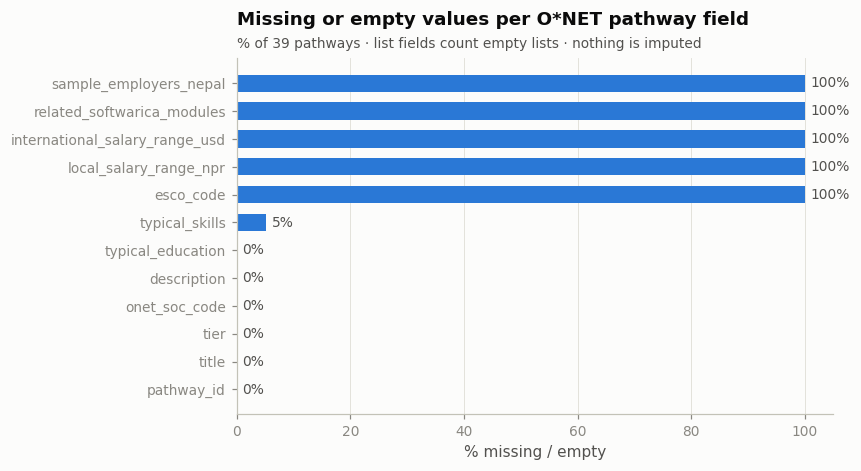

In [12]:
list_cols = ["typical_skills", "typical_education", "related_softwarica_modules",
             "sample_employers_nepal"]
audit = {}
for col in pw.columns:
    if col in list_cols:
        audit[col] = (pw[col].str.len() == 0).mean() * 100
    else:
        audit[col] = pw[col].isna().mean() * 100
audit = pd.Series(audit).sort_values()

fig, ax = plt.subplots(figsize=(7, 4.2))
bars = ax.barh(audit.index, audit.values, color=C[0], height=0.62)
for b, v in zip(bars, audit.values):
    ax.text(b.get_width() + 1, b.get_y() + b.get_height() / 2,
            f"{v:.0f}%", va="center", fontsize=9, color=INK["secondary"])
finish(ax, "Missing or empty values per O*NET pathway field",
       subtitle="% of 39 pathways · list fields count empty lists · nothing is imputed",
       xlabel="% missing / empty", grid_axis="x")
ax.set_xlim(0, 105)
save_fig(fig, "onet_missingness")
plt.show()

### 1.2 Duplicates & integrity checks

`pathway_id` must be unique (it is the retrieval document id), titles should
not repeat, and any salary range must satisfy *low ≤ high*.

In [13]:
dup_ids    = int(pw["pathway_id"].duplicated().sum())
dup_titles = int(pw["title"].str.lower().duplicated().sum())

sal = pw["international_salary_range_usd"].dropna()
bad_ranges = int(sum(1 for lo, hi in sal if lo > hi))

print(f"duplicate pathway_ids : {dup_ids}")
print(f"duplicate titles      : {dup_titles}")
print(f"inverted salary ranges: {bad_ranges}")

if dup_ids:
    pw = pw.drop_duplicates(subset="pathway_id", keep="first").reset_index(drop=True)
    print(f"-> dropped duplicates, {len(pw)} pathways remain")
assert pw["pathway_id"].is_unique and bad_ranges == 0, "integrity check failed"
print("integrity checks passed")

duplicate pathway_ids : 0
duplicate titles      : 0
inverted salary ranges: 0
integrity checks passed


### 1.3 Outlier detection — salary ranges

Tukey's IQR rule flags unusually high international salary ceilings. Flagged
rows are **kept and marked**, not deleted: these are real occupations, and for
a knowledge base an "outlier" salary is information, not noise. The flag lets
EDA and the advising layer treat them with care.

IQR fences: [nan, nan] USD -> 0 flagged (kept, marked)
figure saved -> reports/figures/01_cleaning/onet_salary_outliers.png


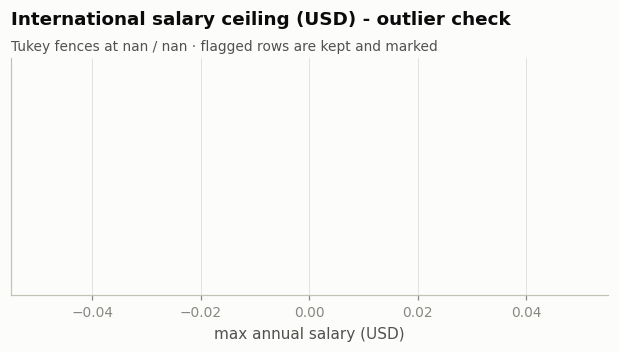

In [14]:
import numpy as np

sal_hi = pw["international_salary_range_usd"].dropna().str[1].astype(float)
q1, q3 = sal_hi.quantile([0.25, 0.75])
iqr = q3 - q1
lo_fence, hi_fence = q1 - 1.5 * iqr, q3 + 1.5 * iqr
flags = (sal_hi < lo_fence) | (sal_hi > hi_fence)
pw["salary_outlier"] = False
pw.loc[sal_hi.index, "salary_outlier"] = flags
print(f"IQR fences: [{lo_fence:,.0f}, {hi_fence:,.0f}] USD -> {int(flags.sum())} flagged (kept, marked)")

fig, ax = plt.subplots(figsize=(7, 2.8))
box = ax.boxplot(sal_hi, vert=False, widths=0.5, patch_artist=True,
                 boxprops=dict(facecolor=C[0], alpha=0.35, edgecolor=C[0]),
                 medianprops=dict(color=C[0], linewidth=2),
                 flierprops=dict(marker="o", markerfacecolor=C[5],
                                 markeredgecolor="none", markersize=7))
ax.set_yticks([])
finish(ax, "International salary ceiling (USD) - outlier check",
       subtitle=f"Tukey fences at {lo_fence:,.0f} / {hi_fence:,.0f} · flagged rows are kept and marked",
       xlabel="max annual salary (USD)", grid_axis="x")
save_fig(fig, "onet_salary_outliers")
plt.show()

## 2 · ESCO v1.2.1 — optional second international tier

Runs only if the ESCO CSV bulk download is present at `data/raw/esco/`
(download: <https://esco.ec.europa.eu/en/use-esco/download> → CSV, English).
It adds finer-grained ICT occupations (ISCO group 25) alongside O*NET.

In [15]:
from drona.data_pipeline import esco

esco_dir = Path("data/raw/esco")
esco_pathways = []
if esco_dir.is_dir() and any(esco_dir.glob("occupations*csv")):
    esco_pathways = esco.parse_csv_dir(esco_dir)
    esco.build_data_card(esco_pathways, PROC / "esco_pathways_data_card.yaml")
    existing = set(pw["title"].str.lower())
    esco_new = [p for p in esco_pathways if p.title.lower() not in existing]
    print(f"ESCO: {len(esco_pathways)} ICT occupations parsed, {len(esco_new)} new after dedupe vs O*NET")
    pathways = pathways + esco_new
else:
    print("ESCO CSVs not found at data/raw/esco/ - skipping (optional).")
    print("Download the English CSV bulk from https://esco.ec.europa.eu/en/use-esco/download")

ESCO CSVs not found at data/raw/esco/ - skipping (optional).
Download the English CSV bulk from https://esco.ec.europa.eu/en/use-esco/download


## 3 · BLS OEWS — international wage enrichment (auto-download)

Attaches authoritative USD wage bands (10th-90th percentile per SOC code) to
the O*NET pathways. The May 2025 national table downloads automatically
(public domain, ~280 KB); if BLS is unreachable, drop the file from
<https://www.bls.gov/oes/tables.htm> into `data/raw/bls/` and re-run.

In [16]:
from drona.data_pipeline import bls

BLS_DIR = Path("data/raw/bls"); BLS_DIR.mkdir(parents=True, exist_ok=True)

def _bls_files():
    return [p for p in BLS_DIR.rglob("*") if p.suffix in (".xlsx", ".xls", ".csv")]

if not _bls_files():
    # BLS rejects non-browser clients - send browser-like headers.
    import io, zipfile
    import httpx
    headers = {"User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                             "AppleWebKit/537.36 (KHTML, like Gecko) Chrome/126.0 Safari/537.36",
               "Referer": "https://www.bls.gov/oes/tables.htm"}
    for tag in ("oesm25nat", "oesm24nat"):        # May 2025, then May 2024 fallback
        try:
            r = httpx.get(f"https://www.bls.gov/oes/special-requests/{tag}.zip",
                          headers=headers, timeout=120, follow_redirects=True)
            if r.status_code == 200 and r.content[:2] == b"PK":
                zipfile.ZipFile(io.BytesIO(r.content)).extractall(BLS_DIR)
                print(f"downloaded + extracted {tag}.zip")
                break
        except Exception as exc:
            print(f"{tag}: {exc}")

bls_files = _bls_files()
if bls_files:
    wages = bls.load_wage_table(bls_files[0])
    pathways = bls.enrich_pathways(pathways, wages)
    enriched = sum(1 for p in pathways if p.international_salary_range_usd)
    bls.build_data_card(wages, PROC / "bls_oews_data_card.yaml")
    print(f"BLS OEWS: wage bands for {len(wages)} SOC codes -> {enriched}/{len(pathways)} pathways enriched")
else:
    print("BLS OEWS unavailable right now - optional; place the table in data/raw/bls/ and re-run.")

2026-07-14 04:57:04.086 | INFO     | drona.data_pipeline.bls:load_wage_table:58 - Loading BLS OEWS wage table from data/raw/bls/oesm25nat/national_M2025_dl.xlsx
2026-07-14 04:57:05.395 | SUCCESS  | drona.data_pipeline.bls:load_wage_table:82 -   Loaded wage bands for 36 computing occupations
2026-07-14 04:57:05.396 | INFO     | drona.data_pipeline.bls:enrich_pathways:107 -   Enriched 38/39 pathways with OEWS wage bands
2026-07-14 04:57:05.402 | INFO     | drona.data_pipeline.bls:build_data_card:139 - BLS OEWS data card written


BLS OEWS: wage bands for 36 SOC codes -> 38/39 pathways enriched


## 4 · NLFS 2017/18 — Nepal-tier labour evidence (optional download)

Extracts citable text snippets (with page provenance) from the official Nepal
Labour Force Survey PDF. Snippets - not scraped tables - because faithful
quoted evidence with a page number is more defensible than brittle numeric
table extraction.

In [17]:
from drona.data_pipeline import nlfs

try:
    pdf_path = nlfs.download_pdf()
    snippets = nlfs.extract_snippets(pdf_path)
    nlfs.build_data_card(snippets, PROC / "nlfs_data_card.yaml")
    print(f"NLFS: {len(snippets)} evidence snippets extracted")
    if snippets:
        s = snippets[0]
        print(f"sample (p.{s.page}): {s.text[:220]}...")
except Exception as exc:
    print(f"NLFS download/extract skipped ({type(exc).__name__}: {exc})")
    print("Optional - the pipeline runs without it; retry later or place the PDF manually.")

2026-07-14 04:57:05.418 | INFO     | drona.data_pipeline.nlfs:download_pdf:69 - Downloading NLFS PDF from https://data.nsonepal.gov.np/dataset/a095d482-4f68-4aec-809b-ae8041d3817c/resource/9f5e1585-2af7-4257-bb6b-59073b1da34f/download/labour-force-survey-2017_18.pdf


NLFS download/extract skipped (ConnectTimeout: [Errno 110] Connection timed out)
Optional - the pipeline runs without it; retry later or place the PDF manually.


## 5 · Softwarica curriculum — parse & audit

Parses every module descriptor in `data/raw/curriculum/` (`.md/.pdf/.docx/.txt`)
into validated `CurriculumModule` records. If the folder is empty the clearly
marked placeholder modules are generated so the pipeline stays runnable.

In [28]:
import sys as _sys
import pandas as pd
from pathlib import Path
from drona.contracts import CurriculumModule # Assuming CurriculumModule is defined here

cur_dir = Path("data/raw/curriculum")
if not cur_dir.is_dir() or not any(cur_dir.iterdir()):
    _sys.path.insert(0, "scripts")
    import make_placeholder_data as mpd
    mpd._write_curriculum(); mpd._write_jobs()
    print("wrote PLACEHOLDER curriculum + jobs (replace with real files for the final model)")

from drona.data_pipeline import curriculum

modules = curriculum.parse_directory(cur_dir)
mod = pd.DataFrame([m.model_dump() for m in modules])

# Initial audit before dropping
dup_codes_before_drop  = int(mod["module_code"].duplicated().sum())
empty_desc = int((mod["description"].str.strip().str.len() < 30).sum())
no_skills  = int((mod["skills_developed"].str.len() == 0).sum())

print(f"{len(modules)} modules parsed | initial duplicate codes: {dup_codes_before_drop} | "
      f"thin descriptions (<30 chars): {empty_desc} | no skills listed: {no_skills}")

if dup_codes_before_drop > 0:
    # Identify and print the duplicate module codes that will be dropped
    duplicated_rows = mod[mod["module_code"].duplicated(keep='first')]
    print(f"Found {dup_codes_before_drop} duplicate module codes. The following modules (second and subsequent occurrences) will be dropped:")
    print(duplicated_rows[['module_code', 'title']].to_string(index=False))

    # Drop duplicate rows based on 'module_code', keeping the first occurrence
    mod = mod.drop_duplicates(subset="module_code", keep="first").reset_index(drop=True)

    # Fill NaN values in 'credits' column with 0 before recreating CurriculumModule objects
    mod['credits'] = mod['credits'].fillna(0)

    # After dropping, recreate the `modules` list from the cleaned `mod` DataFrame
    modules = [CurriculumModule(**row) for row in mod.to_dict(orient='records')]

    print(f"Dropped {dup_codes_before_drop} duplicate module(s). {len(mod)} unique modules remain.")

# Recalculate dup_codes after potential dropping
dup_codes_after_drop = int(mod["module_code"].duplicated().sum())

assert dup_codes_after_drop == 0, "Error: Duplicate module codes still exist after attempted removal."
print("Integrity check passed: no duplicate module codes.")
mod[["module_code", "title", "year", "credits", "is_core"]].head(20)

2026-07-14 05:04:22.436 | INFO     | drona.data_pipeline.curriculum:parse_directory:342 - Found 87 curriculum documents in data/raw/curriculum
2026-07-14 05:04:22.446 | INFO     | drona.data_pipeline.curriculum:parse_file:310 - Parsing curriculum document: _college_softwarica.md
2026-07-14 05:04:22.448 | DEBUG    | drona.data_pipeline.curriculum:extract_text:77 -   Extracted 3,300 chars from _college_softwarica.md
2026-07-14 05:04:22.458 | SUCCESS  | drona.data_pipeline.curriculum:parse_file:315 -   → INFO-SOFTWARICA: Softwarica College - Institutional Overview
2026-07-14 05:04:22.459 | INFO     | drona.data_pipeline.curriculum:parse_file:310 - Parsing curriculum document: _guide_bsc_hons_computer_science_with_artificial_intelligence.md
2026-07-14 05:04:22.460 | DEBUG    | drona.data_pipeline.curriculum:extract_text:77 -   Extracted 3,687 chars from _guide_bsc_hons_computer_science_with_artificial_intelligence.md
2026-07-14 05:04:22.464 | SUCCESS  | drona.data_pipeline.curriculum:parse

87 modules parsed | initial duplicate codes: 8 | thin descriptions (<30 chars): 0 | no skills listed: 8
Found 8 duplicate module codes. The following modules (second and subsequent occurrences) will be dropped:
module_code                                               title
  ST4000CEM                  ST4000CEM Programming & Algorithms
  ST4005CEM                           ST4005CEM Database System
  ST4009CEM ST4009CEM Computing Activity Led Learning Project 2
  ST6000CEM           ST6000CEM: Individual Project Preparation
  ST6001CEM                        ST6001CEM Individual Project
  ST6005CEM                                  ST6005CEM Security
  ST4003CEM               ST4003CEM Object Oriented Programming
  ST4004CEM        ST4004CEM Computer Architecture and Networks
Dropped 8 duplicate module(s). 79 unique modules remain.
Integrity check passed: no duplicate module codes.


,module_code,title,year,credits,is_core
0,INFO-SOFTWARICA,Softwarica College - Institutional Overview,1,0.0,True
1,INFO-CSAI,BSc (Hons) Computer Science with Artificial In...,1,0.0,False
2,INFO-EHC,BSc (Hons) Ethical Hacking and Cybersecurity -...,1,0.0,False
3,INFO-SE,BSc (Hons) Software Engineering - Programme Guide,1,0.0,True
4,GUIDE-AIROLES,Modern AI-Era Tech Roles and How AI Is Reshapi...,1,0.0,True
5,INFO-SE-MSC,MSc Data Science and Computational Intelligenc...,1,0.0,True
6,GUIDE-GRAD,Postgraduate Study Abroad - Pathway Guide,3,0.0,False
7,GUIDE-STARTUP,Startup Founder and Accelerator - Pathway Guide,1,0.0,True
8,lms_building_blocks_,EM001AI Building Blocks for Advanced Computing,1,0.0,True
9,ST4004CEM,ST4004CEM Computer Architecture And Networks,1,15.0,False


## 6 · Nepali job postings — load, dedupe, sanity-check

`manual_loader` reads every ToS-verified posting under `data/manual_collection/`
and validates each into a `JobPosting`. Cleaning steps: exact-duplicate removal
(same title + employer + source), missing-field audit, and salary sanity
(min ≤ max, NPR outlier flags via the same IQR rule as §1.3).

In [21]:
from drona.data_pipeline.scrapers import manual_loader
from drona.utils.settings import settings

posts = manual_loader.load_all_manual(settings.data_manual_dir)
jobs = pd.DataFrame([p.model_dump() for p in posts])

before = len(jobs)
jobs["dedupe_key"] = (jobs["title"].fillna("").str.lower().str.strip() + "|" +
                      jobs["employer"].fillna("").str.lower().str.strip() + "|" + jobs["source"])
jobs = jobs.drop_duplicates(subset="dedupe_key").drop(columns="dedupe_key").reset_index(drop=True)
kept_ids = set(jobs["posting_id"])
posts = [p for p in posts if p.posting_id in kept_ids]
print(f"postings: {before} loaded -> {len(jobs)} after exact-duplicate removal")

miss = jobs[["salary_min_npr", "salary_max_npr", "experience_years_min", "posted_date"]].isna().mean() * 100
print("\nmissing-field audit (%):"); print(miss.round(1).to_string())

both = jobs.dropna(subset=["salary_min_npr", "salary_max_npr"])
inverted = int((both["salary_min_npr"] > both["salary_max_npr"]).sum())
assert inverted == 0, f"{inverted} postings have min > max salary"
print("\nsalary sanity: all ranges satisfy min <= max")

2026-07-14 05:02:04.460 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:37 - Loading manual postings from data/manual_collection/data_jobs/international_postings.json
2026-07-14 05:02:04.466 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:51 -   Loaded 200 / 200 entries from international_postings.json
2026-07-14 05:02:04.467 | SUCCESS  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:87 - Manual loader: 200 unique postings from data/manual_collection/data_jobs
2026-07-14 05:02:04.468 | WARNING  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:66 - No JSON files found in data/manual_collection/internsathi
2026-07-14 05:02:04.469 | WARNING  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:66 - No JSON files found in data/manual_collection/jobsnepal
2026-07-14 05:02:04.470 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:37 - Loading manual postings from data/manual_collection/kumarijobs/kumarijob_re

postings: 297 loaded -> 297 after exact-duplicate removal

missing-field audit (%):
salary_min_npr          94.3
salary_max_npr          95.6
experience_years_min    69.4
posted_date              0.0

salary sanity: all ranges satisfy min <= max


NPR salary outliers flagged (kept): 3 of 13
figure saved -> reports/figures/01_cleaning/jobs_salary_outliers.png


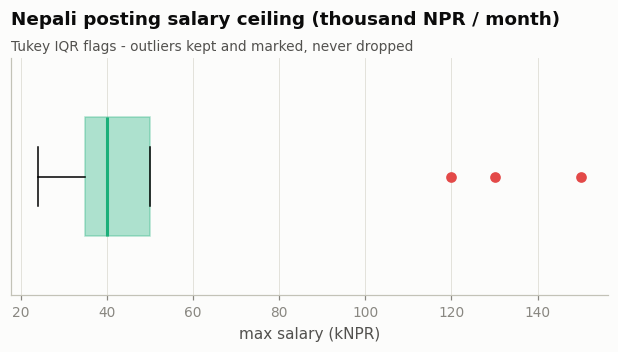

In [22]:
sal_npr = jobs["salary_max_npr"].dropna().astype(float)
if len(sal_npr) >= 8:
    q1, q3 = sal_npr.quantile([0.25, 0.75]); iqr = q3 - q1
    out = (sal_npr > q3 + 1.5 * iqr) | (sal_npr < q1 - 1.5 * iqr)
    jobs["salary_outlier"] = False
    jobs.loc[sal_npr.index, "salary_outlier"] = out
    print(f"NPR salary outliers flagged (kept): {int(out.sum())} of {len(sal_npr)}")

    fig, ax = plt.subplots(figsize=(7, 2.8))
    ax.boxplot(sal_npr / 1000, vert=False, widths=0.5, patch_artist=True,
               boxprops=dict(facecolor=C[1], alpha=0.35, edgecolor=C[1]),
               medianprops=dict(color=C[1], linewidth=2),
               flierprops=dict(marker="o", markerfacecolor=C[5],
                               markeredgecolor="none", markersize=7))
    ax.set_yticks([])
    finish(ax, "Nepali posting salary ceiling (thousand NPR / month)",
           subtitle="Tukey IQR flags - outliers kept and marked, never dropped",
           xlabel="max salary (kNPR)", grid_axis="x")
    save_fig(fig, "jobs_salary_outliers")
    plt.show()
else:
    print(f"only {len(sal_npr)} postings carry salary - skipping outlier plot")

### 6.1 International postings from a popular public dataset

Imports postings from **`lukebarousse/data_jobs`** on Hugging Face (~785k tech
postings, the widely used public corpus) via `scripts/import_public_postings.py`.
They enter the pipeline as **international-tier** evidence: retrieval boosts
Nepal-tier above them (C4), USD salaries stay as description text (never
converted to NPR), and LinkedIn-sourced rows are excluded (ethics policy).
The repo already ships with 200 imported; this cell refreshes them only if
missing. Any Kaggle CSV works too: `--csv file.csv` with column-mapping flags.

In [23]:
import subprocess, sys

intl = Path("data/manual_collection/data_jobs/international_postings.json")
if intl.exists():
    print(f"international postings already present ({intl}) - skipping import")
else:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "datasets"], check=True)
    subprocess.run([sys.executable, "scripts/import_public_postings.py",
                    "--limit", "200"], check=True)

# reload the postings so downstream cells see the full Nepal + international mix
posts = manual_loader.load_all_manual(settings.data_manual_dir)
jobs = pd.DataFrame([p.model_dump() for p in posts])
before = len(jobs)  # reset the dedupe baseline for the cleaning report
tiers = jobs["tier"].astype(str)
print(f"total postings after import: {len(jobs)} "
      f"({tiers.str.contains('nepal').sum()} Nepal-tier, "
      f"{tiers.str.contains('international').sum()} international)")

2026-07-14 05:02:04.729 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:37 - Loading manual postings from data/manual_collection/data_jobs/international_postings.json
2026-07-14 05:02:04.737 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:51 -   Loaded 200 / 200 entries from international_postings.json


international postings already present (data/manual_collection/data_jobs/international_postings.json) - skipping import


2026-07-14 05:02:04.738 | SUCCESS  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:87 - Manual loader: 200 unique postings from data/manual_collection/data_jobs
2026-07-14 05:02:04.741 | WARNING  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:66 - No JSON files found in data/manual_collection/internsathi
2026-07-14 05:02:04.742 | WARNING  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:66 - No JSON files found in data/manual_collection/jobsnepal
2026-07-14 05:02:04.743 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:37 - Loading manual postings from data/manual_collection/kumarijobs/kumarijob_real_postings.json
2026-07-14 05:02:04.745 | INFO     | drona.data_pipeline.scrapers.manual_loader:load_file:51 -   Loaded 28 / 28 entries from kumarijob_real_postings.json
2026-07-14 05:02:04.747 | SUCCESS  | drona.data_pipeline.scrapers.manual_loader:load_manual_dir:87 - Manual loader: 28 unique postings from data/manual_collection/kumari

total postings after import: 297 (97 Nepal-tier, 200 international)


## 7 · Transformations, encoding & scaling

The *learned* features in this project are dense embeddings (built in
notebook 03), so classic tabular encoding plays a supporting role. Three
transformations are still applied and saved because EDA (02) and evaluation
(05) use them:

1. **Text normalisation** — BM25 retrieval tokenises lower-cased text; shown here so the choice is explicit and reproducible.
2. **Ordinal encoding** — education requirements have a natural order, encoded `0-5`.
3. **Standard scaling** — salary ceilings are z-scored for comparability in EDA plots (raw values always kept alongside).

In [24]:
EDU_ORDER = ["high school", "certificate", "associate", "bachelor", "master", "doctorate"]

def edu_rank(levels):
    ranks = [i for i, name in enumerate(EDU_ORDER)
             for lvl in levels if name in str(lvl).lower()]
    return max(ranks) if ranks else np.nan

pw["edu_rank"]    = pw["typical_education"].apply(edu_rank)      # ordinal 0-5
pw["n_skills"]    = pw["typical_skills"].str.len()
pw["n_modules"]   = pw["related_softwarica_modules"].str.len()
pw["desc_len"]    = pw["description"].str.len()
pw["salary_hi_usd"] = pw["international_salary_range_usd"].map(
    lambda t: float(t[1]) if isinstance(t, (list, tuple)) else np.nan)

mu, sd = pw["salary_hi_usd"].mean(), pw["salary_hi_usd"].std(ddof=0)
pw["salary_hi_z"] = (pw["salary_hi_usd"] - mu) / sd               # z-score, raw kept

sample = "What careers suit a Python + ML student in Nepal?"
print("BM25 token normalisation example:", sample.lower().split())
pw[["title", "edu_rank", "n_skills", "salary_hi_usd", "salary_hi_z", "salary_outlier"]].head(6)

BM25 token normalisation example: ['what', 'careers', 'suit', 'a', 'python', '+', 'ml', 'student', 'in', 'nepal?']


,title,edu_rank,n_skills,salary_hi_usd,salary_hi_z,salary_outlier
0,Computer and Information Systems Managers,4,25,NaN,NaN,False
1,Computer Systems Analysts,3,25,NaN,NaN,False
2,Health Informatics Specialists,4,25,NaN,NaN,False
3,Information Security Analysts,4,25,NaN,NaN,False
4,Computer and Information Research Scientists,4,25,NaN,NaN,False
5,Computer Network Support Specialists,3,25,NaN,NaN,False


## 8 · Build the SFT dataset (LoRA input)

Synthetic advising Q&A pairs, grounded in the *real* pathways/modules/postings
cleaned above and balanced across the six cognitive-bias types (C2). Split
90/10 train/validation with a fixed seed; a 50-pair gold subset is exported for
human review.

In [25]:
from drona.finetune import dataset as sft_ds
from drona.finetune import gold_set, qa_generator

pairs = qa_generator.generate_qa_pairs(pathways, modules, posts, target_count=2200)
examples = sft_ds.build_sft_dataset(pairs)
train, val = sft_ds.train_val_split(examples)

FINE = Path("data/finetune"); FINE.mkdir(parents=True, exist_ok=True)
sft_ds.export_jsonl(train, FINE / "sft_train.jsonl")
sft_ds.export_jsonl(val,   FINE / "sft_val.jsonl")
gold_set.write_review_file(gold_set.select_gold_candidates(pairs, n=50),
                           FINE / "gold_review.jsonl")

balance = pd.Series([str(getattr(p.bias_type, "value", p.bias_type)) for p in pairs]).value_counts()
print(f"SFT: train={len(train)} val={len(val)} gold=50")
print("\nbias-type class balance:"); print(balance.to_string())

2026-07-14 05:02:05.985 | SUCCESS  | drona.finetune.qa_generator:generate_qa_pairs:675 - Generated 2200 synthetic advising Q&A pairs (balanced across 6 goal tracks x 7 bias classes)
2026-07-14 05:02:06.160 | SUCCESS  | drona.finetune.dataset:export_jsonl:106 - Wrote 562 SFT examples → data/finetune/sft_train.jsonl
2026-07-14 05:02:06.175 | SUCCESS  | drona.finetune.dataset:export_jsonl:106 - Wrote 62 SFT examples → data/finetune/sft_val.jsonl
2026-07-14 05:02:06.179 | INFO     | drona.finetune.gold_set:select_gold_candidates:52 - Selected 50 gold candidates across 7 bias classes
2026-07-14 05:02:06.190 | SUCCESS  | drona.finetune.gold_set:write_review_file:67 - Wrote 50 pairs to review → data/finetune/gold_review.jsonl


SFT: train=562 val=62 gold=50

bias-type class balance:
None                      318
availability_heuristic    318
anchoring                 316
confirmation              312
dunning_kruger            312
loss_aversion             312
consistency               312


## 9 · Gesture demonstrations (imitation-learning input)

25 keyframe+jitter episodes per gesture (6 gestures × 25 × ~33 frames). Checks:
no NaNs, consistent 6-DOF frames, balanced classes.

In [26]:
import subprocess, sys
subprocess.run([sys.executable, "scripts/collect_demonstrations.py",
                "--episodes", "25", "--out-dir", "data/demonstrations"], check=True)

from drona.interaction.demonstration import DemonstrationDataset
demo = DemonstrationDataset.load_jsonl(Path("data/demonstrations/demonstrations.jsonl"))

n_nan = sum(int(np.isnan(np.asarray(f.observation_state)).any())
            for ep in demo.episodes for f in ep.frames)
dofs = {len(f.observation_state) for ep in demo.episodes for f in ep.frames}
per_gesture = pd.Series([ep.gesture_label for ep in demo.episodes]).value_counts()

print(f"{len(demo.episodes)} episodes / {demo.total_frames} frames | NaN frames: {n_nan} | DOF set: {dofs}")
assert n_nan == 0 and dofs == {6}
print("\nepisodes per gesture:"); print(per_gesture.to_string())

2026-07-14 05:02:09.379 | INFO     | drona.interaction.demonstration:load_jsonl:254 - Loaded 5000 frames from data/demonstrations/demonstrations.jsonl


150 episodes / 5000 frames | NaN frames: 0 | DOF set: {6}

episodes per gesture:
greet       25
nod         25
point       25
idle        25
listen      25
farewell    25


## 10 · Save all processed artifacts

Everything downstream (02-05) reads only from these files - re-running this
notebook after swapping in real curriculum/jobs refreshes the whole pipeline.

In [27]:
import json

from drona.contracts import CareerPathway

# JSON anchors (retrieval + EDA), engineered features, cleaning report
(PROC / "onet_career_pathways.json").write_text(
    json.dumps([p.model_dump(mode="json") for p in pathways], ensure_ascii=False, indent=2),
    encoding="utf-8")
(PROC / "curriculum_modules.json").write_text(
    json.dumps([m.model_dump(mode="json") for m in modules], ensure_ascii=False, indent=2),
    encoding="utf-8")
(PROC / "manual_postings.json").write_text(
    json.dumps([json.loads(p.model_dump_json()) for p in posts], ensure_ascii=False, indent=2),
    encoding="utf-8")
pw.drop(columns=["typical_skills", "typical_education", "related_softwarica_modules",
                 "sample_employers_nepal"]).to_parquet(PROC / "pathway_features.parquet")

report = {
    "n_pathways": len(pathways), "n_modules": len(modules), "n_postings": len(posts),
    "sft_train": len(train), "sft_val": len(val),
    "demo_episodes": len(demo.episodes), "demo_frames": demo.total_frames,
    "salary_outliers_flagged": int(pw["salary_outlier"].sum()),
    "duplicates_dropped": {"pathways": dup_ids, "postings": before - len(jobs)},
}
Path("reports").mkdir(exist_ok=True)
Path("reports/cleaning_report.json").write_text(json.dumps(report, indent=2), encoding="utf-8")
print(json.dumps(report, indent=2))

print("\nartifacts:")
for p in ["data/processed/onet_career_pathways.parquet", "data/processed/onet_career_pathways.json",
          "data/processed/pathway_features.parquet", "data/processed/curriculum_modules.json",
          "data/processed/manual_postings.json", "data/finetune/sft_train.jsonl",
          "data/finetune/sft_val.jsonl", "data/finetune/gold_review.jsonl",
          "data/demonstrations/demonstrations.jsonl"]:
    print(f"  {p:58s} {Path(p).stat().st_size/1024:8.1f} KB")

{
  "n_pathways": 39,
  "n_modules": 79,
  "n_postings": 297,
  "sft_train": 562,
  "sft_val": 62,
  "demo_episodes": 150,
  "demo_frames": 5000,
  "salary_outliers_flagged": 0,
  "duplicates_dropped": {
    "pathways": 0,
    "postings": 0
  }
}

artifacts:
  data/processed/onet_career_pathways.parquet                    24.5 KB
  data/processed/onet_career_pathways.json                       58.4 KB
  data/processed/pathway_features.parquet                        18.5 KB
  data/processed/curriculum_modules.json                       3666.8 KB
  data/processed/manual_postings.json                           283.1 KB
  data/finetune/sft_train.jsonl                                9114.4 KB
  data/finetune/sft_val.jsonl                                  1013.1 KB
  data/finetune/gold_review.jsonl                               305.4 KB
  data/demonstrations/demonstrations.jsonl                     1535.9 KB


---
**Next:** [02 · Exploratory Data Analysis](02_exploratory_data_analysis.ipynb) -
distributions, correlations, class balance, and curriculum↔market alignment on
the artifacts saved above.